# SHAP Generation and Explanations

This notebook demonstrates how to generate SHAP explanations for compound selectivity models in this repository.

It includes:
- Optional end-to-end training (dataset -> features -> split -> model)
- SHAP generation from an existing split/model pair
- Atom-level SHAP visualizations on molecules
- SHAP explanations for custom SMILES strings

## Workflow Overview

1. Configure paths and model settings.
2. Either train a new model or reuse existing split/model artifacts.
3. Compute SHAP values for a selected split.
4. Render atom-level SHAP heatmaps for selected compounds.
5. Explain one custom SMILES and render its SHAP map.

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not locate workspace root with pyproject.toml and src/")

workspace_root = find_workspace_root(Path.cwd())
src_path = workspace_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Workspace root: {workspace_root}")
print(f"Using src path:   {src_path}")

Workspace root: C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Using src path:   C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src


In [2]:
from chemagent.datasets.dataset_tools import (
    find_datasets,
    load_dataset,
    compute_features,
    split_dataset,
)
from chemagent.ml.training_tools import train_model, check_training
from chemagent.explainability.shap_explainer import (
    explain_with_shap,
    explain_smiles_with_shap,
    plot_shap_mol,
)

print("SHAP tools imported successfully.")

c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP tools imported successfully.


In [3]:
# -------------------- User Configuration --------------------
USE_EXISTING_ARTIFACTS = True

# If training a new model, choose a dataset CSV in data/datasets
dataset_csv = "data/datasets/chembl_activity_data_O00329_P42336.csv"

# Featurization settings (must match SHAP settings later)
n_bits = 2048
radius = 2

# Split/train settings
algorithm = "DNN"
task = "classification"
train_size, val_size, test_size = 0.7, 0.0, 0.3
seed = 42

# SHAP settings
analysis_split = "test"
correct_only = True
plot_sample_indices = [0, 1, 2]

# Custom SMILES (if None, auto-picks first available SMILES from split SHAP output)
custom_smiles = None

# Optional fallback artifact paths (used if auto-discovery fails)
manual_split_file_path = None
manual_model_path = None

output_dir = workspace_root / "notebooks" / "debug_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [4]:
def latest_file(pattern: str) -> str | None:
    matches = list(workspace_root.glob(pattern))
    if not matches:
        return None
    return str(max(matches, key=lambda p: p.stat().st_mtime))

def latest_model_file(selected_algorithm: str) -> str | None:
    algo = (selected_algorithm or "").strip()

    # Prefer the selected algorithm first (new nested and older flat layouts).
    preferred_patterns = []
    if algo:
        preferred_patterns.append(f"data/logs/session_*/models/{algo}/**/*.pkl")
        preferred_patterns.append(f"data/logs/session_*/models/{algo}/*.pkl")
        preferred_patterns.append(f"data/logs/session_*/models/*_{algo}.pkl")

    # Backward-compatible generic fallbacks.
    fallback_patterns = [
        "data/logs/session_*/models/**/*.pkl",
        "data/logs/session_*/models/*.pkl",
    ]

    seen = set()
    preferred_matches = []
    for pattern in preferred_patterns:
        for path in workspace_root.glob(pattern):
            resolved = str(path.resolve())
            if resolved not in seen:
                seen.add(resolved)
                preferred_matches.append(path)

    if preferred_matches:
        return str(max(preferred_matches, key=lambda p: p.stat().st_mtime))

    fallback_matches = []
    for pattern in fallback_patterns:
        for path in workspace_root.glob(pattern):
            resolved = str(path.resolve())
            if resolved not in seen:
                seen.add(resolved)
                fallback_matches.append(path)

    if not fallback_matches:
        return None

    return str(max(fallback_matches, key=lambda p: p.stat().st_mtime))

if USE_EXISTING_ARTIFACTS:
    split_file_path = latest_file("data/logs/session_*/splits/*.pkl") or manual_split_file_path
    model_path = latest_model_file(algorithm) or manual_model_path

    if not split_file_path or not model_path:
        raise FileNotFoundError(
            "Could not auto-discover split/model artifacts. "
            "Set USE_EXISTING_ARTIFACTS=False to train, or set manual_* paths."
        )

    print("Using existing artifacts:")
    print("algorithm       =", algorithm)
    print("split_file_path =", split_file_path)
    print("model_path      =", model_path)
else:
    available = find_datasets()
    print("Available datasets:")
    print(available)

    load_info = load_dataset(file_path=dataset_csv)
    dataset_id = load_info["dataset_id"]
    print("Loaded dataset_id:", dataset_id)

    feat_info = compute_features(dataset_id=dataset_id, method="ECFP", n_bits=n_bits, radius=radius)
    print("Feature summary:", feat_info)

    split_info = split_dataset(
        dataset_id=dataset_id,
        split_type="random",
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        seed=seed,
        stratified=True,
    )
    split_file_path = split_info["saved_to"]
    print("Split file:", split_file_path)

    job = train_model(
        split_file_path=split_file_path,
        algorithm=algorithm,
        task=task,
        opt_metric="balanced_accuracy",
        random_seed=seed,
    )
    print("Training job submitted:", job)

    while True:
        status = check_training(job["job_id"], model_save_path=job["model_save_path"])
        print(status["status"], "elapsed:", status.get("elapsed_seconds", "n/a"))
        if status["status"] in {"completed", "failed"}:
            break
        time.sleep(30)

    if status["status"] != "completed":
        raise RuntimeError(f"Training failed: {status}")

    model_path = status.get("model_path") or status.get("result", {}).get("model_path") or job["model_save_path"]
    print("Model path:", model_path)

Using existing artifacts:
algorithm       = DNN
split_file_path = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\splits\chembl_activity_data_O00329_P48736_scaffold.pkl
model_path      = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\models\chembl_activity_data_O00329_P48736_scaffold_DNN.pkl


In [5]:
split_shap_path = output_dir / "shap_from_split.pkl"

shap_info = explain_with_shap(
    model_path=model_path,
    split_file_path=split_file_path,
    split=analysis_split,
    n_bits=n_bits,
    correct_only=correct_only,
    save_path=str(split_shap_path),
)

shap_info

{'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_split.pkl',
 'n_samples': 223,
 'n_samples_total': 256,
 'n_correct': 223,
 'correct_only': True,
 'n_features': 2048,
 'expected_value': 13.358810424804688,
 'mean_abs_shap': 0.020030481521787026,
 'has_smiles': True,
 'next_step': "Call plot_shap_mol('C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_split.pkl') to visualise atom-level SHAP heatmaps for individual compounds."}

In [10]:
shap_data = joblib.load(shap_info["shap_values_path"])
n_show = min(5, shap_data["shap_values"].shape[0])

if "smiles" in shap_data:
    smiles_preview = shap_data["smiles"][:n_show]
else:
    smiles_preview = np.array(["<no_smiles>"] * n_show)

if "labels" in shap_data:
    labels_preview = shap_data["labels"][:n_show]
else:
    labels_preview = np.array(["?"] * n_show)

preview = pd.DataFrame(
    {
        "smiles": smiles_preview,
        "label": labels_preview,
        "mean_abs_shap": np.abs(shap_data["shap_values"][:n_show]).mean(axis=1),
        "top_bit": np.abs(shap_data["shap_values"][:n_show]).argmax(axis=1),
        #"expected_value": shap_data.get("expected_value", [np.nan] * n_show)[:n_show],
    }
)

preview

,smiles,label,mean_abs_shap,top_bit
0,Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N...,1,0.000413,546
1,CC(Nc1ncnc(N)c1C#N)c1cc2ncc(Cl)n2nc1-c1cnn(C)c1,1,0.000467,358
2,CC(Nc1ncnc(N)c1C#N)c1cc2ncc(Cl)n2cc1-c1ccccc1,1,0.000457,358
3,CC(Nc1ncnc(N)c1C#N)c1nc2cccc(Cl)c2c(=O)n1Cc1cc...,1,0.000445,358
4,CC(=O)N1CCN(C(=O)c2cccc(-c3ncnc4ccc(-c5cnc6ccc...,1,0.000411,1016


In [12]:
shap_data.get("expected_value")

0.7514669652855543

In [7]:
plot_outputs = plot_shap_mol(
    shap_values_path=shap_info["shap_values_path"],
    sample_indices=plot_sample_indices,
    mol_size=[700, 700],
    cmap="coolwarm",
)

plot_summary = plot_outputs[0]
plot_summary

{'generated': ['C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png',
  'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_1_label1.png',
  'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_2_label1.png'],
 'molecules': {'0': {'path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png',
   'smiles': 'Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N5CCOCC5)c4s3)CC1CC2',
   'label': '1',
   'cid': '0'},
  '1': {'path': 'C:\\Users\\janela\\OneDrive - uni-b

C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\plots\shap_mol_0_label1.png


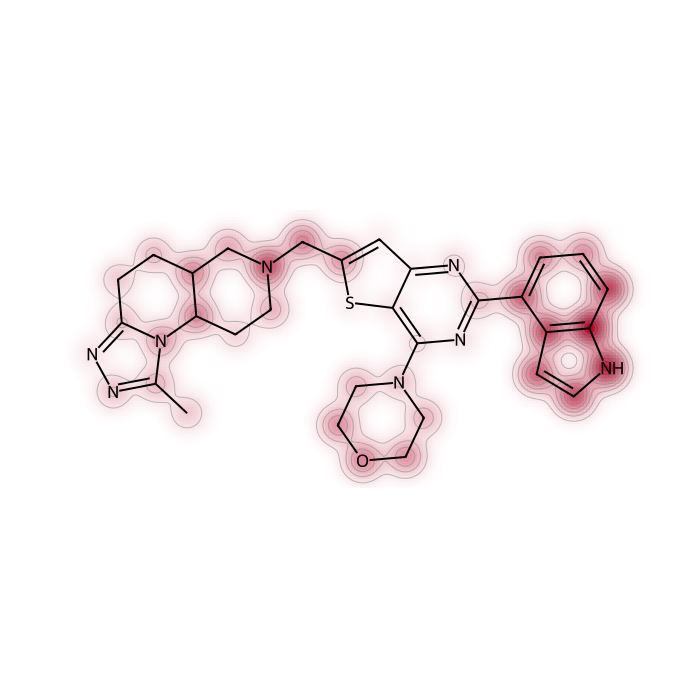

C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\plots\shap_mol_1_label1.png


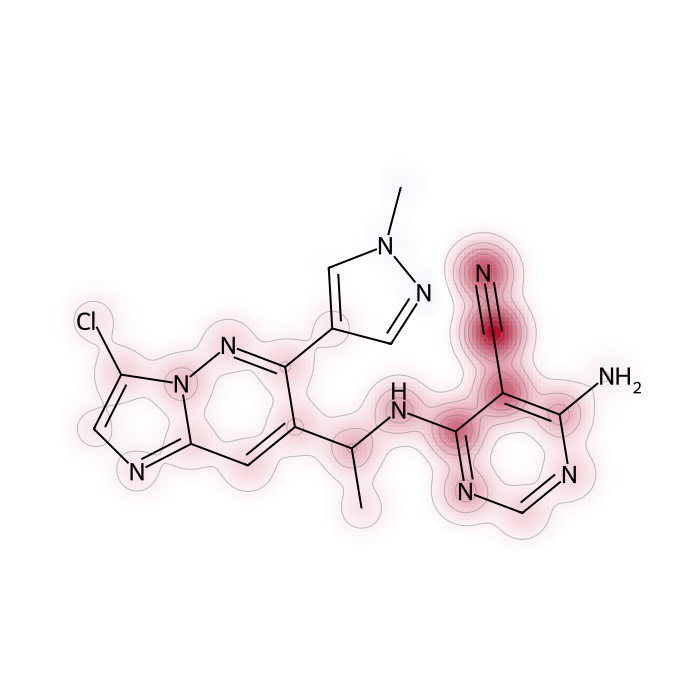

C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\plots\shap_mol_2_label1.png


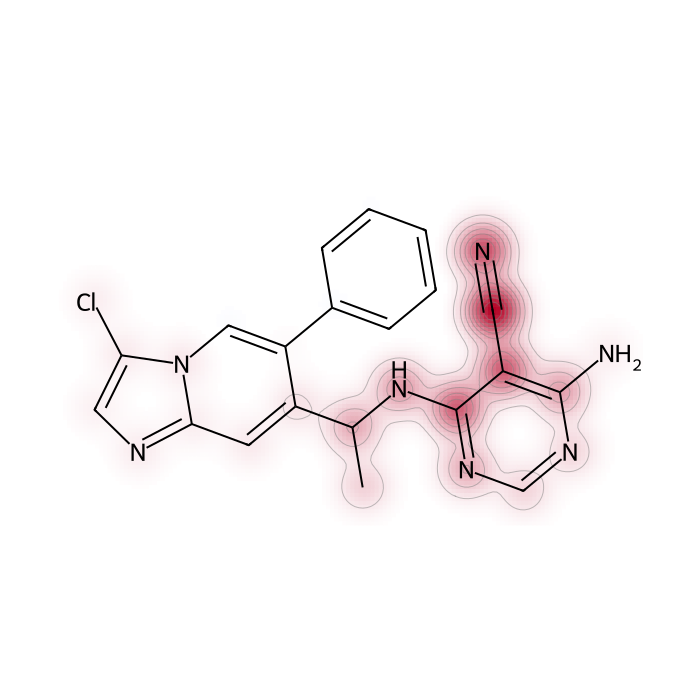

In [8]:
for img_path in plot_summary["generated"]:
    print(img_path)
    display(Image(filename=img_path))

In [9]:
if custom_smiles is None:
    if "smiles" in shap_data and len(shap_data["smiles"]) > 0:
        custom_smiles = str(shap_data["smiles"][0])
    else:
        raise ValueError("No SMILES available to auto-select. Set custom_smiles manually.")

print("SMILES for direct explanation:", custom_smiles)

smiles_shap_path = output_dir / "shap_from_smiles.pkl"
smiles_info = explain_smiles_with_shap(
    model_path=model_path,
    smiles=[custom_smiles],
    method="ECFP",
    split_file_path=split_file_path,
    n_bits=n_bits,
    radius=radius,
    save_path=str(smiles_shap_path),
)

smiles_info

SMILES for direct explanation: Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N5CCOCC5)c4s3)CC1CC2


{'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_smiles.pkl',
 'n_samples': 1,
 'n_features': 2048,
 'expected_value': 0.7514669652855543,
 'prediction': 1,
 'mean_abs_shap': 0.0004130274882188449,
 'shap_sum': 0.596400709219608,
 'method': 'ECFP',
 'has_smiles': True,
 'note': 'Labels in output file are model predictions, not ground truth.',
 'next_step': "Call plot_shap_mol('C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_smiles.pkl') to render atom-level SHAP heatmaps. Labels shown reflect the model's predicted class."}

In [10]:
smiles_plot_outputs = plot_shap_mol(
    shap_values_path=smiles_info["shap_values_path"],
    sample_indices=[0],
    mol_size=[700, 500],
    cmap="coolwarm",
)

smiles_plot_summary = smiles_plot_outputs[0]
smiles_plot_summary

{'generated': ['C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png'],
 'molecules': {'0': {'path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png',
   'smiles': 'Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N5CCOCC5)c4s3)CC1CC2',
   'label': '1',
   'cid': '0'}}}

C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\plots\shap_mol_0_label1.png


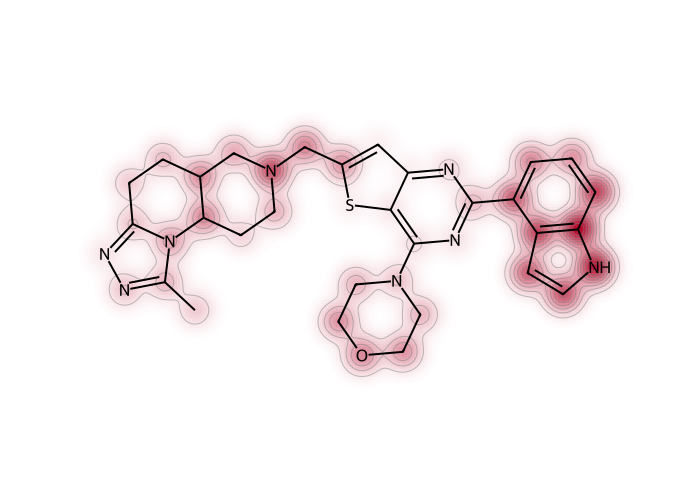

In [11]:
for img_path in smiles_plot_summary["generated"]:
    print(img_path)
    display(Image(filename=img_path))

## Interpretation Notes

- Large absolute SHAP values indicate fingerprint bits with strong influence on predictions.
- The SHAP molecule plots map bit-level contributions to atom-level heatmaps.
- For valid mapping, keep featurization consistent with training (`method`, `n_bits`, `radius`).
- For `explain_smiles_with_shap`, labels in output are model predictions, not ground truth.